# 🏛️ **UNIVERSIDAD NACIONAL DE LOJA**

####⚡ **Facultad de Energía, las Industrias y los Recursos Naturales no Renovables**
---
### 💻 **Carrera de Computación**

---

 **Actividad Autónoma:** Teoremas de Aproximación Asintótica en Big Data

**👥 Grupo G — Integrantes:**
  * Chamba Galarza Emerson Sebastian
  * Labanda Pineda Matias Sebastian
  * Macas Cabrera Lenin Fabricio
  * Naranjo Quizhpe Pilar Valentina
  * Pucha Carrera Mateo Sebastian

**Profesor:** Ing. Cristian Narváez G. Mg.Sc.

**Paralelo:** A

**Fecha:** 15/06/2026


## 📊 **Fase 1: Extracción del Parámetro Base Regional**


In [5]:
import pandas as pd

df = pd.read_csv("/content/datos_loja.csv")

total_viviendas = df["Viviendas"].sum()
sin_alcantarillado = df["Sin_Alcantarillado"].sum()

p = sin_alcantarillado / total_viviendas

print("Total viviendas:", total_viviendas)
print("Sin alcantarillado:", sin_alcantarillado)
print("Probabilidad histórica p:", p)

Total viviendas: 163112
Sin alcantarillado: 38122
Probabilidad histórica p: 0.23371670999068125


##📑 **Evento Dicotómico Seleccionado**

Para el análisis estadístico se definió como evento dicotómico la disponibilidad del servicio de alcantarillado en las viviendas registradas en la provincia de Loja.

* **Éxito (E):** La vivienda no dispone de servicio de alcantarillado.
* **Fracaso (F):** La vivienda dispone de servicio de alcantarillado.

A partir de los datos históricos se calculó la probabilidad de éxito como:

p = (Viviendas sin alcantarillado) / (Total de viviendas)

p = 38122 / 163112

p = 0.2337

Por lo tanto, la probabilidad histórica de que una vivienda seleccionada al azar no disponga de alcantarillado es aproximadamente del 23.37%.


## 📊 **Fase 2: El Desafío de la Escala Computacional (Planteamiento del Problema)**

In [9]:
import time

# Parametros del escenario de expansion
N = 10000   # numero de ensayos independientes
k = 4200    # numero exacto de exitos que se busca

# p proviene de la Fase 1 (probabilidad historica de exito)
# Ejemplo: p = dias_uv_alta / total_registros
print("N =", N)
print("k =", k)
print("p =", p)

def factorial(n):
    resultado = 1
    for i in range(2, n + 1):
        resultado *= i
    return resultado

inicio = time.time()
fact_N = factorial(N)
fact_k = factorial(k)
fact_Nk = factorial(N - k)
fin = time.time()

print("Tiempo de calculo de los tres factoriales:", fin - inicio, "segundos")
print("Cantidad de digitos de N! :", len(str(fact_N)))

combinaciones = fact_N // (fact_k * fact_Nk)
print("Cantidad de digitos de C(N,k):", len(str(combinaciones)))

probabilidad_exacta = combinaciones * (p ** k) * ((1 - p) ** (N - k))
print("Probabilidad de obtener exactamente k exitos:", probabilidad_exacta)



N = 10000
k = 4200
p = 0.23371670999068125
Tiempo de calculo de los tres factoriales: 0.03781247138977051 segundos
Cantidad de digitos de N! : 35660
Cantidad de digitos de C(N,k): 2953


OverflowError: int too large to convert to float

### 🧠 **Análisis Crítico del Rendimiento de CPU y Restricciones de Arquitectura**

Al ejecutar el código nativo con $N = 10,000$, se demuestra físicamente la inviabilidad del modelo discreto exacto:

* **Complejidad Temporal:** Calcular factoriales de forma iterativa consume ciclos de CPU innecesarios mediante un costo lineal $\mathcal{O}(N)$, lo que genera cuellos de botella para el procesamiento en tiempo real.
* **Desbordamiento de Memoria (Overflow):** El coeficiente combinatorio resultante posee **2,953 dígitos**. Al multiplicarlo por las potencias probabilísticas, el sistema intenta convertirlo a punto flotante (`float`). Debido a que la arquitectura del procesador limita los flotantes a **8 bytes** (con un máximo de $1.79 \times 10^{308}$), el número excede la capacidad física del hardware, provocando el error `OverflowError`.



## 📊**Fase 3: Implementación del Modelo de Aproximación Normal**

###**Verificación de las Condiciones de Aproximación**

Para validar la aproximación de una distribución binomial a una distribución normal se debe verificar que:

$$n \cdot p > 5$$

$$n \cdot (1 - p) > 5$$

Utilizando $n = 10000$ y $p = 0.2337$ se obtiene:

* **$n \cdot p = 2337$**
* **$n \cdot (1 - p) = 7663$**

Como ambos valores son mayores que 5, se cumplen las condiciones necesarias para aplicar la aproximación normal.

In [ ]:
n = 10000
p = 0.2337

np_val = n * p
nq_val = n * (1 - p)

print("np =", np_val)
print("n(1-p) =", nq_val)

np = 2337.0
n(1-p) = 7663.0


##**Cálculo de la Media y la Desviación Estándar**

Una vez comprobado que la aproximación normal es válida, se calculan los parámetros que definen la distribución normal equivalente.

La media (μ) representa el número promedio esperado de éxitos en los 10.000 ensayos.

La desviación estándar (σ) mide cuánto pueden variar los resultados respecto a dicho promedio.

Estos parámetros permiten construir una distribución normal que modele el comportamiento de la distribución binomial original.

In [ ]:
import math

mu = n * p
sigma = math.sqrt(n * p * (1 - p))

print("Media =", mu)
print("Desviación estándar =", sigma)

Media = 2337.0
Desviación estándar = 42.31835417404604


##**Aplicación de la Corrección por Continuidad**

Debido a que la distribución binomial es discreta y la distribución normal es continua, se aplica la corrección por continuidad de Yates para mejorar la precisión de la aproximación.

Se calculará la probabilidad de que el número de éxitos se encuentre dentro del intervalo comprendido entre 2250 y 2400 casos.

Para ello, los límites del intervalo se ajustan ligeramente antes de calcular el área correspondiente bajo la curva normal.

In [ ]:
import math

a = 2250
b = 2400

def norm_cdf(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

z1 = ((a - 0.5) - mu) / sigma
z2 = ((b + 0.5) - mu) / sigma

probabilidad = norm_cdf(z2) - norm_cdf(z1)

print("z1 =", z1)
print("z2 =", z2)
print("Probabilidad =", probabilidad)

z1 = -2.0676607516476615
z2 = 1.500530945481446
Probabilidad = 0.9139255706206264


##📑**Interpretación de los Resultados**

La probabilidad obtenida representa la posibilidad de que el número de éxitos observados en una muestra de 10.000 casos se encuentre dentro del intervalo analizado.

Este método permite realizar predicciones de manera eficiente sin necesidad de calcular la distribución binomial exacta, reduciendo significativamente el costo computacional.

##💻**Visualización de la Distribución Normal**

A continuación se representa gráficamente la distribución normal equivalente obtenida a partir de los parámetros calculados.

Las líneas verticales muestran el intervalo utilizado para el cálculo de probabilidades, permitiendo visualizar la región de interés dentro de la curva normal.

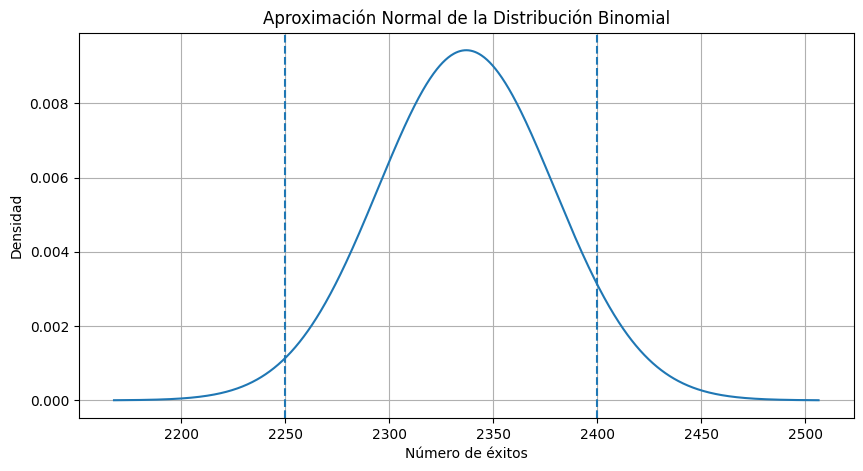

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

y = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

plt.figure(figsize=(10,5))
plt.plot(x, y)

plt.axvline(2250, linestyle="--")
plt.axvline(2400, linestyle="--")

plt.title("Aproximación Normal de la Distribución Binomial")
plt.xlabel("Número de éxitos")
plt.ylabel("Densidad")

plt.grid(True)
plt.show()

##📑**Interpretación del Gráfico**

La curva representa la distribución normal equivalente construida a partir de la media y la desviación estándar calculadas previamente.

El punto más alto de la curva corresponde al valor medio esperado de éxitos, mientras que las líneas verticales delimitan el intervalo analizado para la estimación de probabilidades.

Esta visualización permite comprender de forma gráfica cómo se distribuyen los posibles resultados alrededor del valor esperado.

## 📊**Fase 4: Conclusiones de Ingeniería e Impacto Tecnológico**


✨ **Desde la perspectiva de la optimización algorítmica y el costo computacional, ¿cuál es la ventaja estructural de aplicar funciones de densidad continuas (norm.cdf) Frente al cálculo iterativo de funciones de masa discretas en entornos de Big Data?**


Desde la perspectiva de la optimización algorítmica, el uso de `norm.cdf` permite reemplazar cálculos combinatorios complejos de distribuciones discretas por una evaluación continua altamente optimizada.

Este enfoque técnico presenta las siguientes ventajas estructurales:

* **Eficiencia de Procesamiento:** Reduce significativamente el costo computacional al reemplazar cálculos combinatorios y sumatorias de distribuciones discretas por una evaluación continua altamente optimizada. En la práctica, `norm.cdf`  se ejecuta en tiempo prácticamente constante, incluso cuando el tamaño de la muestra es muy grande.
* **Optimización de Memoria:** Evita por completo el manejo de factoriales y coeficientes combinatorios extremadamente grandes (como el entero de 2,953 dígitos de la Fase 2), eliminando el riesgo de desbordamiento numérico (`OverflowError`).
* **Soporte para Big Data:** En entornos de alta escala, esta aproximación mejora drásticamente la escalabilidad del sistema, permitiendo procesar y modelar grandes volúmenes de datos de forma eficiente con un consumo mínimo de hardware.

---

✨**¿Cómo mitiga este modelo predictivo asintótico el riesgo de la toma de decisiones con datos limitados en la gestión tecnológica de la provincia de Loja?**

El uso de modelos predictivos asintóticos basados en el Teorema del Límite Central permite reducir la incertidumbre en la toma de decisiones tecnológicas cuando la información disponible es limitada o costosa de obtener, fundamentándose en los siguientes pilares estructurales:

* **Mayor Confiabilidad Estadística:** Cuando se cumplen las condiciones de estabilidad ($n \cdot p > 5$ y $n \cdot (1-p) > 5$), la distribución puede aproximarse adecuadamente mediante una curva normal. Esto facilita realizar estimaciones y proyecciones matemáticas sobre fenómenos provinciales de gran escala, como el acceso a servicios, la demanda de infraestructura digital o el comportamiento de indicadores sociales.

* **Reducción de Costos en la Recolección de Datos:** En lugar de ejecutar censos completos o monitorear a toda la población en tiempo real, esta aproximación permite extraer conclusiones razonablemente precisas a partir de muestras representativas. Esto disminuye significativamente los costos económicos, logísticos y tecnológicos asociados a la captura y procesamiento de información.

* **Optimización y Planificación de Recursos:** Las proyecciones estadísticas permiten anticipar necesidades futuras y asignar presupuestos de infraestructura de manera eficiente en los distintos cantones de la provincia de Loja, reduciendo el riesgo de inversiones mal dimensionadas o decisiones basadas únicamente en la intuición.

* **Impacto en la Gestión Tecnológica de Loja:** Gracias a estas aproximaciones estadísticas, las instituciones de la provincia pueden diseñar proyectos de conectividad, redes de servicios y planes de transformación digital con un respaldo cuantitativo sólido, minimizando la incertidumbre y fortaleciendo la planificación estratégica regional.